In [40]:
import numpy as np
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import pandas as pd
import os
import re
import polars as pl
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
import polars as pl
import polars as pl
import numpy as np
from scipy.optimize import minimize
import numpy as np
from scipy.optimize import minimize



In [6]:
mc_path = "/home/aegis/Titan1/NRAD/data/Regions_MC_ver3"
data_path = "/home/aegis/Titan1/NRAD/data/Regions_data_ver4"

mc_processes = ["Diboson", "Multijet", "Single_top", "ttbar", "Wjets", "Zjets"]

columns_to_load_mc = [
    "raw_weights", 
    "weight_sub",
    # "weight_ngen", "weight_sub_weight", "weight_tot_weight",
    "met_recalc_pt", "met_recalc_phi",
    "ht", # <- Make sure HT is here so you don't have to recalculate it!
    
    # --- CHANGE THESE TO THE POST-OR BRANCHES ---
    "signal_jet_pt", 
    "signal_jet_eta", 
    "signal_jet_phi", 
    
    # --- LARGE R JETS STAY THE SAME ---
    "AnalysisLargeRJetsAuxDyn_pt", 
    "AnalysisLargeRJetsAuxDyn_eta", 
    "AnalysisLargeRJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau2_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

# Make sure you do the same for your data columns!
columns_to_load_data = [
    "met_recalc_pt", "met_recalc_phi",
    "ht",
    "signal_jet_pt", 
    "signal_jet_eta", 
    "signal_jet_phi", 

    "AnalysisLargeRJetsAuxDyn_pt", 
    "AnalysisLargeRJetsAuxDyn_eta", 
    "AnalysisLargeRJetsAuxDyn_phi", 
    "AnalysisLargeRJetsAuxDyn_Tau1_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau2_wta", 
    "AnalysisLargeRJetsAuxDyn_Tau3_wta"
]

In [4]:
### --- Loading MC events --- ###
MC_ATLAS_CR0L_paths = glob.glob(os.path.join(mc_path, "ATLAS_CR_MJRR", "*.parquet"))
MC_ATLAS_CR1L_paths = glob.glob(os.path.join(mc_path, "ATLAS_CR_1L", "*.parquet"))
MC_ATLAS_CR1L1B_paths = glob.glob(os.path.join(mc_path, "ATLAS_CR_1L1B", "*.parquet"))
MC_ATLAS_CR2L_paths = glob.glob(os.path.join(mc_path, "ATLAS_CR_2L", "*.parquet"))

MC_ML_CR0L_paths = glob.glob(os.path.join(mc_path, "ML_CR_0L", "*.parquet"))
MC_ML_CR1L_paths = glob.glob(os.path.join(mc_path, "ML_CR_1L", "*.parquet"))
MC_ML_CR1L1B_paths = glob.glob(os.path.join(mc_path, "ML_CR_1L1B", "*.parquet"))
MC_ML_CR2L_paths = glob.glob(os.path.join(mc_path, "ML_CR_2L", "*.parquet"))

MC_SR_paths = glob.glob(os.path.join(mc_path, "SR", "*.parquet"))

### --- Loading data events --- ###
DATA_ATLAS_CR0L_paths = glob.glob(os.path.join(data_path, "ATLAS_CR_MJRR", "*.parquet"))
DATA_ATLAS_CR1L_paths = glob.glob(os.path.join(data_path, "ATLAS_CR_1L", "*.parquet"))
DATA_ATLAS_CR1L1B_paths = glob.glob(os.path.join(data_path, "ATLAS_CR_1L1B", "*.parquet"))
DATA_ATLAS_CR2L_paths = glob.glob(os.path.join(data_path, "ATLAS_CR_2L", "*.parquet"))

DATA_ML_CR0L_paths = glob.glob(os.path.join(data_path, "ML_CR_0L", "*.parquet"))
DATA_ML_CR1L_paths = glob.glob(os.path.join(data_path, "ML_CR_1L", "*.parquet"))
DATA_ML_CR1L1B_paths = glob.glob(os.path.join(data_path, "ML_CR_1L1B", "*.parquet"))
DATA_ML_CR2L_paths = glob.glob(os.path.join(data_path, "ML_CR_2L", "*.parquet"))

DATA_SR_paths = glob.glob(os.path.join(data_path, "SR_0L", "*.parquet"))

# Check that we loaded the paths correctly
if not (MC_ATLAS_CR0L_paths and MC_ATLAS_CR1L_paths and MC_ATLAS_CR1L1B_paths and MC_ATLAS_CR2L_paths and
        MC_ML_CR0L_paths and MC_ML_CR1L_paths and MC_ML_CR1L1B_paths and MC_ML_CR2L_paths and 
        MC_SR_paths):
    raise ValueError("Error: One or more MC paths are empty. Please check the paths.")

if not (DATA_ATLAS_CR0L_paths and DATA_ATLAS_CR1L_paths and DATA_ATLAS_CR1L1B_paths and DATA_ATLAS_CR2L_paths and 
        DATA_ML_CR0L_paths and DATA_ML_CR1L_paths and DATA_ML_CR1L1B_paths and DATA_ML_CR2L_paths and 
        DATA_SR_paths):
    raise ValueError("Error: One or more data paths are empty. Please check the paths.")
print("Paths loaded successfully!")


Paths loaded successfully!


In [7]:
df = pl.read_parquet(MC_ATLAS_CR1L_paths[0], columns=columns_to_load_mc)
print("Columns in the MC CR1L sample:", df.columns)

Columns in the MC CR1L sample: ['raw_weights', 'weight_sub', 'met_recalc_pt', 'met_recalc_phi', 'ht', 'signal_jet_pt', 'signal_jet_eta', 'signal_jet_phi', 'AnalysisLargeRJetsAuxDyn_pt', 'AnalysisLargeRJetsAuxDyn_eta', 'AnalysisLargeRJetsAuxDyn_phi', 'AnalysisLargeRJetsAuxDyn_Tau1_wta', 'AnalysisLargeRJetsAuxDyn_Tau2_wta', 'AnalysisLargeRJetsAuxDyn_Tau3_wta']


In [ ]:
def calc_features(lf: pl.LazyFrame, is_MC) -> pl.LazyFrame:
    """
    Calculates Mjj and tau ratios using the cleaned Parquet features, 
    then discards all low-level vectors.
    """
    # lf = lf.filter(
    #     # (pl.col("signal_jet_pt").list.len() >= 2) &
    #     (pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.len() >= 2)
    # )
    # 1. Extract the specific elements using the CLEANED branches (post_OR)
    lf = lf.with_columns(
        j1_pt  = pl.col("signal_jet_pt").list.get(0),
        j2_pt  = pl.col("signal_jet_pt").list.get(1),
        j1_eta = pl.col("signal_jet_eta").list.get(0),
        j2_eta = pl.col("signal_jet_eta").list.get(1),
        j1_phi = pl.col("signal_jet_phi").list.get(0),
        j2_phi = pl.col("signal_jet_phi").list.get(1),
        
        # Large-R Jet Taus (No OR was applied to these, so raw branches are fine)
        lrj1_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(0),
        lrj1_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(0),
        lrj1_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(0),
        lrj2_t1 = pl.col("AnalysisLargeRJetsAuxDyn_Tau1_wta").list.get(1),
        lrj2_t2 = pl.col("AnalysisLargeRJetsAuxDyn_Tau2_wta").list.get(1),
        lrj2_t3 = pl.col("AnalysisLargeRJetsAuxDyn_Tau3_wta").list.get(1),
    )

    # 2. Calculate the final complex math
    lf = lf.with_columns(
        # Mjj formula: Removed / 1000.0 because post_OR_jet_pt is already in GeV
        mjj = (
            2 * pl.col("j1_pt") * pl.col("j2_pt") * ((pl.col("j1_eta") - pl.col("j2_eta")).cosh() - (pl.col("j1_phi") - pl.col("j2_phi")).cos())
        ).sqrt(),
        
        # Subjettiness ratios (with safe division)
        ljet1_tau21 = pl.when(pl.col("lrj1_t1") > 0).then(pl.col("lrj1_t2") / pl.col("lrj1_t1")).otherwise(0),
        ljet1_tau32 = pl.when(pl.col("lrj1_t2") > 0).then(pl.col("lrj1_t3") / pl.col("lrj1_t2")).otherwise(0),
        ljet2_tau21 = pl.when(pl.col("lrj2_t1") > 0).then(pl.col("lrj2_t2") / pl.col("lrj2_t1")).otherwise(0),
        ljet2_tau32 = pl.when(pl.col("lrj2_t2") > 0).then(pl.col("lrj2_t3") / pl.col("lrj2_t2")).otherwise(0),
    )

    # 3. KEEP ONLY WHAT YOU ASKED FOR. Everything else is flushed from memory.
    if is_MC:
        final_columns = [
            "mc_process", "subprocess",                                              
            "raw_weights", 
            "weight_sub",
            # "weight_ngen", "weight_sub_weight", "weight_tot_weight",
            "met_recalc_pt", "met_recalc_phi",                                       
            "ht", "mjj",                                                             # HT is native to the parquet now
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               
        ]
    else:
        final_columns = [                                                            
            "met_recalc_pt", "met_recalc_phi",                                       
            "ht", "mjj",                                                             
            "ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"               
        ]
        
    return lf.select(final_columns)

def get_lazyframes(paths, is_mc):
    # Move this OUTSIDE the loop so it doesn't overwrite on every iteration
    files_by_meta = defaultdict(list)
    known_processes = ['Wjets', 'Zjets', 'ttbar', 'Diboson', 'Multijet', 'Single_top']
    
    for filepath in paths:
        filename = os.path.basename(filepath)
        
        if is_mc:
            # Identify the main mc_process
            mc_process = next((p for p in known_processes if filename.startswith(p)), "Other")
            
            # Clean the filename to extract just the subprocess
            name_no_ext = filename.replace(".parquet", "")
            
            if name_no_ext.startswith(mc_process + "_"):
                remainder = name_no_ext[len(mc_process) + 1:]
            else:
                remainder = name_no_ext
                
            # STRIP THE BATCH: This removes "_batch1762" from the end of the string
            subprocess = re.sub(r"_batch\d+$", "", remainder) 
            
            # Group all batches of the same subprocess together
            files_by_meta[(mc_process, subprocess)].append(filepath)
        else:
            # If it's real data, bypass the naming logic and group them all together
            # print(filepath)
            files_by_meta[("Data", "Data")].append(filepath)

    # Load the data into the DataFrame list
    lazy_frames = []

    # group_paths now contains ALL batch files for this specific key
    for (mc_process, subprocess), group_paths in files_by_meta.items():
        if is_mc:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_mc)
            # Tag them with the clean labels only if it's Monte Carlo
            lf = lf.with_columns(
                pl.lit(mc_process).alias("mc_process"),
                pl.lit(subprocess).alias("subprocess")
            )
        else:
            lf = pl.scan_parquet(group_paths).select(columns_to_load_data)
            
        lf = calc_features(lf, is_mc)
        lazy_frames.append(lf)

    return lazy_frames

#### Process CR1L

In [9]:
MC_ATLAS_CR1L_lazy = get_lazyframes(MC_ATLAS_CR1L_paths, is_mc=True)
MC_ML_CR1L_lazy = get_lazyframes(MC_ML_CR1L_paths, is_mc=True)
DATA_ATLAS_CR1L_lazy = get_lazyframes(DATA_ATLAS_CR1L_paths, is_mc=False)
DATA_ML_CR1L_lazy = get_lazyframes(DATA_ML_CR1L_paths, is_mc=False)

MC_ATLAS_CR1L = pl.concat(MC_ATLAS_CR1L_lazy).collect()
MC_ML_CR1L = pl.concat(MC_ML_CR1L_lazy).collect()
DATA_ATLAS_CR1L = pl.concat(DATA_ATLAS_CR1L_lazy).collect()
DATA_ML_CR1L = pl.concat(DATA_ML_CR1L_lazy).collect()

#### Process CR1L1B

In [10]:
MC_ATLAS_CR1L1B_lazy = get_lazyframes(MC_ATLAS_CR1L1B_paths, is_mc=True)
MC_ML_CR1L1B_lazy = get_lazyframes(MC_ML_CR1L1B_paths, is_mc=True)
DATA_ATLAS_CR1L1B_lazy = get_lazyframes(DATA_ATLAS_CR1L1B_paths, is_mc=False)
DATA_ML_CR1L1B_lazy = get_lazyframes(DATA_ML_CR1L1B_paths, is_mc=False)

MC_ATLAS_CR1L1B = pl.concat(MC_ATLAS_CR1L1B_lazy).collect()
MC_ML_CR1L1B = pl.concat(MC_ML_CR1L1B_lazy).collect()
DATA_ATLAS_CR1L1B = pl.concat(DATA_ATLAS_CR1L1B_lazy).collect()
DATA_ML_CR1L1B = pl.concat(DATA_ML_CR1L1B_lazy).collect()

#### Process CR2L

In [11]:
MC_ATLAS_CR2L_lazy = get_lazyframes(MC_ATLAS_CR2L_paths, is_mc=True)
MC_ML_CR2L_lazy = get_lazyframes(MC_ML_CR2L_paths, is_mc=True)
DATA_ATLAS_CR2L_lazy = get_lazyframes(DATA_ATLAS_CR2L_paths, is_mc=False)
DATA_ML_CR2L_lazy = get_lazyframes(DATA_ML_CR2L_paths, is_mc=False)

MC_ATLAS_CR2L = pl.concat(MC_ATLAS_CR2L_lazy).collect()
MC_ML_CR2L = pl.concat(MC_ML_CR2L_lazy).collect()
DATA_ATLAS_CR2L = pl.concat(DATA_ATLAS_CR2L_lazy).collect()
DATA_ML_CR2L = pl.concat(DATA_ML_CR2L_lazy).collect()

#### Process CR0L

In [12]:
MC_ATLAS_CR0L_lazy = get_lazyframes(MC_ATLAS_CR0L_paths, is_mc=True)
MC_ML_CR0L_lazy = get_lazyframes(MC_ML_CR0L_paths, is_mc=True)
DATA_ATLAS_CR0L_lazy = get_lazyframes(DATA_ATLAS_CR0L_paths, is_mc=False)
DATA_ML_CR0L_lazy = get_lazyframes(DATA_ML_CR0L_paths, is_mc=False)

MC_ATLAS_CR0L = pl.concat(MC_ATLAS_CR0L_lazy).collect()
MC_ML_CR0L = pl.concat(MC_ML_CR0L_lazy).collect()
DATA_ATLAS_CR0L = pl.concat(DATA_ATLAS_CR0L_lazy).collect()
DATA_ML_CR0L = pl.concat(DATA_ML_CR0L_lazy).collect()

#### Process SR

In [13]:
MC_SR_lazy = get_lazyframes(MC_SR_paths, is_mc=True)
DATA_SR_lazy = get_lazyframes(DATA_SR_paths, is_mc=False)

MC_SR = pl.concat(MC_SR_lazy).collect()
DATA_SR = pl.concat(DATA_SR_lazy).collect()

In [180]:
# 1. Load the official metadata from the CSV
meta_df = pl.read_csv("metadata_processed.csv").select([
    "physics_short", 
    "crossSection_pb", 
    "genFiltEff", 
    "kFactor",
    "sumOfWeights",
    "sum_w_pros", 
    "scale_factor_sub_weight", 
    "luminosity"
]).rename({"physics_short": "subprocess"})

# def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
#     """
#     Plots Data vs MC using native ATLAS scale factor calculations.
#     Saves individual, thesis-ready PDFs for each variable with dynamic legend spacing
#     and automatic log-scale handling.
#     """
    
#     # Thesis/Publication styling settings
#     plt.rcParams.update({
#         'font.size': 14,
#         'axes.labelsize': 16,
#         'xtick.labelsize': 14,
#         'ytick.labelsize': 14,
#         'legend.fontsize': 12,
#         'lines.linewidth': 1.5,
#         'xtick.direction': 'in',
#         'ytick.direction': 'in',
#         'xtick.top': True,
#         'ytick.right': True,
#         'axes.formatter.use_mathtext': True,
#         'axes.linewidth': 1.2
#     })
    
#     variables = [
#         'ht', 'met_recalc_pt', 'mjj', 
#         'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
#     ]
    
#     # Define which variables should be plotted with a log y-axis
#     log_variables = ['ht', 'met_recalc_pt', 'mjj']
    
#     mc_processes = ["Diboson", "Single_top", "ttbar", "Zjets", "Wjets", "Multijet"]
    
#     # Standard HEP color palette for distinct backgrounds
#     color_map = {
#         "Diboson": "#e31a1c",   # Red
#         "Multijet": "#fdbf6f",  # Light Orange
#         "Single_top": "#ff7f00",# Dark Orange
#         "ttbar": "#cab2d6",     # Light Purple
#         "Wjets": "#33a02c",     # Dark Green
#         "Zjets": "#1f78b4"      # Dark Blue
#     }
    
#     # Mapping for publication-ready axis labels
#     pretty_labels = {
#         'ht': r'$H_{T}$ [GeV]',
#         'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
#         'mjj': r'$m_{jj}$ [GeV]',
#         'ljet1_tau21': r'Leading jet $\tau_{21}$',
#         'ljet1_tau32': r'Leading jet $\tau_{32}$',
#         'ljet2_tau21': r'Subleading jet $\tau_{21}$',
#         'ljet2_tau32': r'Subleading jet $\tau_{32}$'
#     }

#     for branch in variables:
#         valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
#         valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
#         valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
#         valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
#         if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
#             continue
            
#         combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
#         bins = np.histogram_bin_edges(combined_data, bins=15)
#         bin_centers = (bins[:-1] + bins[1:]) / 2
        
#         fig = plt.figure(figsize=(8, 8))
#         gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
        
#         ax_main = fig.add_subplot(gs[0])
#         ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
        
#         mc_hists = []
#         mc_weights = []
#         labels = []
        
#         for proc in mc_processes:
#             proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
#             if proc_df.height == 0:
#                 continue
                
#             data_proc = proc_df.get_column(branch).to_numpy()
#             weights_proc = proc_df.get_column('final_weight').to_numpy()
            
#             mc_hists.append(data_proc)
#             mc_weights.append(weights_proc)
#             labels.append(proc)
            
#         # 1. Main Plot: Stacked MC
#         mc_colors = [color_map.get(l, '#999999') for l in labels]
#         if mc_hists:
#             ax_main.hist(
#                 mc_hists, bins=bins, weights=mc_weights, 
#                 stacked=True, label=labels, color=mc_colors, 
#                 histtype='stepfilled', edgecolor='black', linewidth=0.5
#             )
        
#         # 2. Main Plot: Data
#         counts_data, _ = np.histogram(valid_data_arr, bins=bins)
#         ax_main.errorbar(
#             bin_centers, counts_data, yerr=np.sqrt(counts_data), 
#             fmt='ko', label='Data', zorder=10, capsize=0, markersize=5
#         )
        
#         # --- DYNAMIC Y-AXIS SCALING (Linear vs Log) ---
#         mc_total_weights = valid_mc_df.get_column('final_weight').to_numpy() if 'final_weight' in valid_mc_df.columns else np.ones_like(valid_mc_arr)
#         total_mc, _ = np.histogram(valid_mc_arr, bins=bins, weights=mc_total_weights)
        
#         max_data = np.max(counts_data) + np.max(np.sqrt(counts_data)) if len(counts_data) > 0 else 0
#         max_mc = np.max(total_mc) if len(total_mc) > 0 else 0
#         y_max = max(max_data, max_mc)
        
#         if branch in log_variables:
#             ax_main.set_yscale('log')
#             # Log plots need a lower limit > 0 and massive headroom multiplier (e.g., 100x)
#             ax_main.set_ylim(0.1, y_max * 100)
#         else:
#             # Linear plots need a 0 lower limit and standard headroom (e.g., 1.55x)
#             ax_main.set_ylim(0, y_max * 1.55) 
#             ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
#         # Main Plot Aesthetics
#         ax_main.set_ylabel('Events / Bin')
#         plt.setp(ax_main.get_xticklabels(), visible=False)
#         ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        
#         # Add Region/Metadata Text
#         if region_name:
#             # textstr = r"$\mathbf{ATLAS}$ Internal" + f"\nRegion: {region_name}\n" + r"$\sqrt{s} = 13$ TeV"
#             textstr = f"Region: {region_name}\n" + r"$\sqrt{s} = 13$ TeV"
#             ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes,
#                          fontsize=14, verticalalignment='top')

#         # Custom Legend Formatting (Force Data to be first)
#         handles, loc_labels = ax_main.get_legend_handles_labels()
#         if "Data" in loc_labels:
#             data_idx = loc_labels.index("Data")
#             handles.insert(0, handles.pop(data_idx))
#             loc_labels.insert(0, loc_labels.pop(data_idx))
            
#         ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)

#         # 3. Ratio Plot: Data / Total MC
#         with np.errstate(divide='ignore', invalid='ignore'):
#             ratio = counts_data / total_mc
#             ratio_err = np.sqrt(counts_data) / total_mc
#             ratio = np.where(total_mc > 0, ratio, np.nan)
#             ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
#         ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=0, markersize=5)
        
#         # Ratio Plot Aesthetics
#         ax_ratio.axhline(1, color='gray', linestyle='--', linewidth=1.5)
#         ax_ratio.set_ylabel('Data / MC')
#         ax_ratio.set_xlabel(pretty_labels.get(branch, branch))
#         ax_ratio.set_ylim(0.5, 1.5)
#         ax_ratio.set_yticks([0.75, 1.0, 1.25])
        
#         ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
#         ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
#         fig.align_ylabels((ax_main, ax_ratio))
        
#         filename_region = f"_{region_name.replace(' ', '_')}" if region_name else ""
#         save_name = f"data_mc_{branch}{filename_region}.pdf"
        
#         # plt.savefig(save_name, bbox_inches='tight', format='pdf')
#         # print(f"Saved thesis plot: {save_name}")
#         plt.show()
        
#         plt.close(fig)

def plot_mc_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations.
    Saves individual, thesis-ready PDFs for each variable with dynamic legend spacing,
    automatic log-scale handling, and MC Statistical uncertainty bands.
    """
    
    # Thesis/Publication styling settings
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'lines.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.formatter.use_mathtext': True,
        'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5 # Thinner hatch lines look cleaner
    })
    
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    
    log_variables = ['ht', 'met_recalc_pt', 'mjj']
    mc_processes = ["Diboson", "Single_top", "ttbar", "Zjets", "Wjets", "Multijet"]
    
    color_map = {
        "Diboson": "#e31a1c", "Multijet": "#fdbf6f", "Single_top": "#ff7f00",
        "ttbar": "#cab2d6", "Wjets": "#33a02c", "Zjets": "#1f78b4"
    }
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]', 'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]',
        'mjj': r'$m_{jj}$ [GeV]', 'ljet1_tau21': r'Leading jet $\tau_{21}$',
        'ljet1_tau32': r'Leading jet $\tau_{32}$', 'ljet2_tau21': r'Subleading jet $\tau_{21}$',
        'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }

    for branch in variables:
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        bin_widths = np.diff(bins) 
        
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
        
        ax_main = fig.add_subplot(gs[0])
        ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
        
        mc_hists = []
        mc_weights = []
        labels = []
        
        for proc in mc_processes:
            proc_df = valid_mc_df.filter(pl.col('mc_process') == proc)
            if proc_df.height == 0: continue
                
            mc_hists.append(proc_df.get_column(branch).to_numpy())
            mc_weights.append(proc_df.get_column('final_weight').to_numpy())
            labels.append(proc)
            
        mc_colors = [color_map.get(l, '#999999') for l in labels]
        if mc_hists:
            ax_main.hist(
                mc_hists, bins=bins, weights=mc_weights, 
                stacked=True, label=labels, color=mc_colors, 
                histtype='stepfilled', edgecolor='black', linewidth=0.5
            )
        
        # --- MC STATISTICAL UNCERTAINTY ONLY ---
        mc_total_weights = valid_mc_df.get_column('final_weight').to_numpy() if 'final_weight' in valid_mc_df.columns else np.ones_like(valid_mc_arr)
        total_mc, _ = np.histogram(valid_mc_arr, bins=bins, weights=mc_total_weights)
        
        # Stat error: sum of squared weights per bin
        mc_stat_var, _ = np.histogram(valid_mc_arr, bins=bins, weights=mc_total_weights**2)
        mc_err = np.sqrt(mc_stat_var) # Just the stat error

        # Plot MC Statistical Uncertainty Band on Main Plot
        ax_main.bar(bin_centers, 2 * mc_err, bottom=total_mc - mc_err, width=bin_widths,
                    color='none', edgecolor='gray', hatch='////', linewidth=0,
                    alpha=0.5, zorder=5, label='Stat. Unc.')
        # ---------------------------------------

        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data', zorder=10, capsize=0, markersize=5
        )
        
        max_data = np.max(counts_data) + np.max(np.sqrt(counts_data)) if len(counts_data) > 0 else 0
        max_mc = np.max(total_mc + mc_err) if len(total_mc) > 0 else 0 
        y_max = max(max_data, max_mc)
        
        if branch in log_variables:
            ax_main.set_yscale('log')
            ax_main.set_ylim(0.1, y_max * 1000)
        else:
            ax_main.set_ylim(0, y_max * 1.55) 
            ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
        ax_main.set_ylabel('Events / Bin')
        plt.setp(ax_main.get_xticklabels(), visible=False)
        ax_main.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        
        if region_name:
            textstr = f"{region_name}\n" + r"$\sqrt{s} = 13$ TeV"
            ax_main.text(0.04, 0.94, textstr, transform=ax_main.transAxes,
                         fontsize=14, verticalalignment='top')

        handles, loc_labels = ax_main.get_legend_handles_labels()
        if "Data" in loc_labels:
            data_idx = loc_labels.index("Data")
            handles.insert(0, handles.pop(data_idx))
            loc_labels.insert(0, loc_labels.pop(data_idx))
            
        ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)

        # 3. Ratio Plot: Data / Total MC
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
            # Fractional MC statistical uncertainty
            rel_mc_err = np.where(total_mc > 0, mc_err / total_mc, 0)
        
        # Plot MC Stat Uncertainty band around 1.0
        ax_ratio.bar(bin_centers, 2 * rel_mc_err, bottom=1.0 - rel_mc_err, width=bin_widths,
                     color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)
        
        ax_ratio.axhline(1, color='gray', linestyle='--', linewidth=1.0, zorder=2)
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko', capsize=0, markersize=5, zorder=10)
        
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(pretty_labels.get(branch, branch))
        ax_ratio.set_ylim(0.5, 1.5)
        ax_ratio.set_yticks([0.75, 1.0, 1.25])
        
        ax_ratio.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_ratio.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
        fig.align_ylabels((ax_main, ax_ratio))
        
        filename_region = f"_{region_name.replace(' ', '_')}" if region_name else ""
        save_name = f"data_mc_{branch}{filename_region}.pdf"
        plt.savefig(f"Kinematic_Plots/{save_name}")
        plt.show()
        plt.close(fig)

def plot_subprocess_data_comparison(df_mc: pl.DataFrame, df_data: pl.DataFrame, region_name: str = ""):
    """
    Plots Data vs MC using native ATLAS scale factor calculations, stacked by subprocess.
    """
    variables = [
        'ht', 'met_recalc_pt', 'mjj', 
        'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
    ]
    var_names = {
        "ht": "H_{T} [GeV]",
        "met_recalc_pt": "E_{T}^{miss} [GeV]",
        "mjj": "m_{jj} [GeV]",
        "ljet1_tau21": "Leading Jet #tau_{21}",
        "ljet1_tau32": "Leading Jet #tau_{32}",
        "ljet2_tau21": "Subleading Jet #tau_{21}",
        "ljet2_tau32": "Subleading Jet #tau_{32}"
    }
    # 1. Get unique subprocesses
    sub_processes = df_mc.get_column("subprocess").drop_nulls().unique().to_list()
    sub_processes.sort() 
    n_procs = len(sub_processes)
    
    if n_procs <= 10:
        # Use tab10 for small datasets (much higher contrast than tab20)
        palette = plt.cm.tab10.colors[:n_procs]
        
    elif n_procs <= 20:
        # tab20 pairs similar colors (e.g., index 0 is dark blue, 1 is light blue).
        # We grab all the dark/bold colors first (even indices), then the light ones (odd indices).
        indices = list(range(0, 20, 2)) + list(range(1, 20, 2))
        palette = [plt.cm.tab20.colors[i] for i in indices[:n_procs]]
        
    else:
        # Use nipy_spectral instead of turbo for sharper color transitions.
        # We slice from 0.05 to 0.95 to avoid the extremely dark edges.
        base_colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_procs))
        
        # Shuffle the colors deterministically so adjacent processes are forced apart.
        # The fixed seed (42) ensures your plot colors don't change every time you run the script.
        rng = np.random.default_rng(seed=42)
        palette = rng.permutation(base_colors)
        
    # Map each subprocess to its designated color so it stays consistent across branches
    color_dict = {proc: color for proc, color in zip(sub_processes, palette)}
    
    fig = plt.figure(figsize=(24, 14))
    if region_name:
        fig.suptitle(f"{region_name}", fontsize=20, fontweight='bold')
    
    gs = gridspec.GridSpec(4, 10, height_ratios=[3, 1, 3, 1], hspace=0.3, wspace=0.4)
    
    def get_axes(idx):
        if idx < 2:
            col_start = idx * 5
            col_end = col_start + 5
            ax_main = fig.add_subplot(gs[0, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[1, col_start:col_end], sharex=ax_main)
        else:
            idx_offset = idx - 2
            col_start = idx_offset * 2
            col_end = col_start + 2
            ax_main = fig.add_subplot(gs[2, col_start:col_end])
            ax_ratio = fig.add_subplot(gs[3, col_start:col_end], sharex=ax_main)
        return ax_main, ax_ratio

    global_handles = []
    global_labels = []

    for i, branch in enumerate(variables):
        ax_main, ax_ratio = get_axes(i)
        
        valid_mc_df = df_mc.filter(pl.col(branch).is_not_null())
        valid_data_df = df_data.filter(pl.col(branch).is_not_null())
        
        valid_mc_arr = valid_mc_df.get_column(branch).to_numpy()
        valid_data_arr = valid_data_df.get_column(branch).to_numpy()
        
        if len(valid_mc_arr) == 0 and len(valid_data_arr) == 0:
            continue
            
        combined_data = np.concatenate([valid_mc_arr, valid_data_arr])
        bins = np.histogram_bin_edges(combined_data, bins=15)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        mc_hists = []
        mc_weights = []
        mc_colors = [] # Store the specific colors for this branch
        labels = []
        
        for proc in sub_processes:
            proc_df = valid_mc_df.filter(pl.col('subprocess') == proc)
            data_proc = proc_df.get_column(branch).to_numpy()
            weights_proc = proc_df.get_column('final_weight').to_numpy()
            
            if len(data_proc) > 0:
                mc_hists.append(data_proc)
                mc_weights.append(weights_proc)
                labels.append(str(proc))
                mc_colors.append(color_dict[proc]) # Grab the mapped color
        
        if mc_hists:
            # 3. PASS THE COLORS ARRAY TO THE HISTOGRAM
            counts_mc, _, _ = ax_main.hist(
                mc_hists, bins=bins, weights=mc_weights, 
                stacked=True, label=labels, color=mc_colors,
                histtype='stepfilled', edgecolor='black', linewidth=0.5
            )
        else:
            counts_mc = [np.zeros_like(bin_centers)]
            
        counts_data, _ = np.histogram(valid_data_arr, bins=bins)
        ax_main.errorbar(
            bin_centers, counts_data, yerr=np.sqrt(counts_data), 
            fmt='ko', label='Data'
        )
        
        ax_main.set_ylabel('Events')
        ax_main.set_title(f"Distribution of {branch}", fontsize=14)
        
        if i == 0:
            global_handles, global_labels = ax_main.get_legend_handles_labels()
            
        total_mc = counts_mc[-1] if len(mc_hists) > 0 else np.zeros_like(counts_data)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = counts_data / total_mc
            ratio_err = np.sqrt(counts_data) / total_mc
            ratio = np.where(total_mc > 0, ratio, np.nan)
            ratio_err = np.where(total_mc > 0, ratio_err, np.nan)
            
        ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='ko')
        ax_ratio.axhline(1, color='gray', linestyle='--')
        ax_ratio.set_ylabel('Data / MC')
        ax_ratio.set_xlabel(branch)
        ax_ratio.set_ylim(0.5, 1.5) 
        plt.setp(ax_main.get_xticklabels(), visible=False)

    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.82) 
    
    fig.legend(
        global_handles, 
        global_labels, 
        loc='center left', 
        bbox_to_anchor=(0.83, 0.5), 
        frameon=False, 
        title="Subprocesses",
        title_fontsize='x-large',
        fontsize=10,
        ncol=1 
    )

    plt.show()

In [63]:
def apply_intial_weights(df_mc: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    LUMI = 25.289004522843967
    
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("sum_w_pros")
    )

    return df_mc.with_columns(
        final_weight = pl.col("official_scale_factor") * pl.col("raw_weights")
    )

In [43]:
MC_ATLAS_CR0L_final = MC_ATLAS_CR0L.filter(
    (pl.col("met_recalc_pt") >= 300)
)
MC_ML_CR0L_final = MC_ML_CR0L.filter(
    (pl.col("met_recalc_pt") >= 300)
)
DATA_ATLAS_CR0L_final = DATA_ATLAS_CR0L.filter(
    (pl.col("met_recalc_pt") >= 300)
)
DATA_ML_CR0L_final = DATA_ML_CR0L.filter(
    (pl.col("met_recalc_pt") >= 300)
)

MC_SR_clean = MC_SR.filter(
    (pl.col("ht") > 600) &
    (pl.col("met_recalc_pt") > 600) &
    (pl.col("met_recalc_pt") < 2000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 4000)
)
DATA_SR_clean = DATA_SR.filter(
    (pl.col("ht") > 600) &
    (pl.col("met_recalc_pt") > 600) &
    (pl.col("met_recalc_pt") < 2000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 4000)
)

In [128]:
MC_ATLAS_CR0L_final_w1 = apply_intial_weights(MC_ATLAS_CR0L_final, meta_df)
MC_ATLAS_CR1L_w1 = apply_intial_weights(MC_ATLAS_CR1L, meta_df)
MC_ATLAS_CR1L1B_w1 = apply_intial_weights(MC_ATLAS_CR1L1B, meta_df)
MC_ATLAS_CR2L_w1 = apply_intial_weights(MC_ATLAS_CR2L, meta_df)
MC_ML_CR0L_final_w1 = apply_intial_weights(MC_ML_CR0L_final, meta_df)
MC_ML_CR1L_w1 = apply_intial_weights(MC_ML_CR1L, meta_df)
MC_ML_CR1L1B_w1 = apply_intial_weights(MC_ML_CR1L1B, meta_df)
MC_ML_CR2L_w1 = apply_intial_weights(MC_ML_CR2L, meta_df)
MC_SR_clean_w1 = apply_intial_weights(MC_SR_clean, meta_df)   

In [133]:
procs_to_remove = ["Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ0WithSW"]
# procs_to_remove = []
MC_ATLAS_CR1L_f = MC_ATLAS_CR1L_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ML_CR1L_f = MC_ML_CR1L_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ATLAS_CR1L1B_f = MC_ATLAS_CR1L1B_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ML_CR1L1B_f = MC_ML_CR1L1B_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ATLAS_CR2L_f = MC_ATLAS_CR2L_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ML_CR2L_f = MC_ML_CR2L_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ATLAS_CR0L_final_f = MC_ATLAS_CR0L_final_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_ML_CR0L_final_f = MC_ML_CR0L_final_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))
MC_SR_clean_f = MC_SR_clean_w1.filter(~pl.col("subprocess").is_in(procs_to_remove))  

In [184]:
MC_ATLAS_TOTAL_CR_df_before = pl.concat([
    MC_ATLAS_CR0L_final_f, 
    MC_ATLAS_CR1L_f, 
    MC_ATLAS_CR1L1B_f, 
    MC_ATLAS_CR2L_f
])
DATA_ATLAS_TOTAL_CR_df_before = pl.concat([
    DATA_ATLAS_CR0L_final, 
    DATA_ATLAS_CR1L, 
    DATA_ATLAS_CR1L1B, 
    DATA_ATLAS_CR2L
])

MC_ML_TOTAL_CR_df_before = pl.concat([
    MC_ML_CR0L_final_f, 
    MC_ML_CR1L_f, 
    MC_ML_CR1L1B_f, 
    MC_ML_CR2L_f
])
DATA_ML_TOTAL_CR_df_before = pl.concat([
    DATA_ML_CR0L_final, 
    DATA_ML_CR1L, 
    DATA_ML_CR1L1B, 
    DATA_ML_CR2L
])

In [113]:
# plot_subprocess_data_comparison(MC_ATLAS_TOTAL_CR_df_before, DATA_ATLAS_TOTAL_CR_df_before, "ALL")

In [114]:
# plot_subprocess_data_comparison(MC_ML_TOTAL_CR_df_before, DATA_ML_TOTAL_CR_df_before, "ALL")

In [100]:
def calculate_fitted_lumi(df_mc: pl.DataFrame, df_data: pl.DataFrame, current_lumi: float) -> float:
    # 1. Sum up the weights from MC (which already include the current_lumi)
    total_mc_yield = df_mc.select(pl.col("final_weight").sum()).item()
    
    # 2. Count the data rows (assuming data events have a weight of 1.0)
    # Using .height to get the number of rows in the Polars DataFrame
    total_data_yield = df_data.height 
    
    # 3. Calculate the correction factor
    scale_factor = total_data_yield / total_mc_yield
    
    # 4. Calculate the new luminosity
    fitted_lumi = current_lumi * scale_factor
    
    print(f"Total Data: {total_data_yield}")
    print(f"Total MC:   {total_mc_yield:.2f}")
    print(f"Correction: {scale_factor:.4f}")
    print(f"Fitted Lumi: {fitted_lumi:.4f}")
    
    return fitted_lumi

# Usage:
OLD_LUMI = 25.289004522843967
new_lumi_ATLAS = calculate_fitted_lumi(MC_ATLAS_TOTAL_CR_df_before, DATA_ATLAS_TOTAL_CR_df_before, OLD_LUMI)
new_lumi_ML = calculate_fitted_lumi(MC_ML_TOTAL_CR_df_before, DATA_ML_TOTAL_CR_df_before, OLD_LUMI)

Total Data: 109914
Total MC:   109500.63
Correction: 1.0038
Fitted Lumi: 25.3845
Total Data: 4804268
Total MC:   6113352.91
Correction: 0.7859
Fitted Lumi: 19.8737


In [134]:
def apply_final_weights(df_mc: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    # LUMI = 25.289004522843967
    LUMI = 25.3845 # ATLAS
    # LUMI = 19.8737 # ML (Fitted)
    
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("sum_w_pros")
    )

    return df_mc.with_columns(
        final_weight = pl.col("official_scale_factor") * pl.col("raw_weights")
    )

In [ ]:
MC_ATLAS_CR1L_w = apply_final_weights(MC_ATLAS_CR1L_f, meta_df)
# MC_ML_CR1L_w = apply_final_weights(MC_ML_CR1L_f, meta_df)
MC_ATLAS_CR1L1B_w = apply_final_weights(MC_ATLAS_CR1L1B_f, meta_df)
# MC_ML_CR1L1B_w = apply_final_weights(MC_ML_CR1L1B_f, meta_df)
MC_ATLAS_CR2L_w = apply_final_weights(MC_ATLAS_CR2L_f, meta_df)
# MC_ML_CR2L_w = apply_final_weights(MC_ML_CR2L_f, meta_df)
MC_ATLAS_CR0L_w = apply_final_weights(MC_ATLAS_CR0L_final_f, meta_df)
# MC_ML_CR0L_w = apply_final_weights(MC_ML_CR0L_final_f, meta_df)
MC_SR_w = apply_final_weights(MC_SR_clean_f, meta_df)

In [148]:
import polars as pl
import numpy as np
from scipy.optimize import minimize

# 1. Add region tags
MC_CR1L_SF = MC_ML_CR1L_f.with_columns(region=pl.lit("CR1L"))
MC_CR1L1B_SF = MC_ML_CR1L1B_f.with_columns(region=pl.lit("CR1L1B"))
MC_CR2L_SF = MC_ML_CR2L_f.with_columns(region=pl.lit("CR2L"))
MC_CR0L_test_SF = MC_ML_CR0L_final_f.with_columns(region=pl.lit("CR0L"))

DATA_CR1L_SF = DATA_ML_CR1L.with_columns(region=pl.lit("CR1L"))
DATA_CR1L1B_SF = DATA_ML_CR1L1B.with_columns(region=pl.lit("CR1L1B"))
DATA_CR2L_SF = DATA_ML_CR2L.with_columns(region=pl.lit("CR2L"))
DATA_CR0L_test_SF = DATA_ML_CR0L_final.with_columns(region=pl.lit("CR0L"))

# 2. Concatenate
mc_total_df_SF = pl.concat([MC_CR1L_SF, MC_CR1L1B_SF, MC_CR2L_SF, MC_CR0L_test_SF])
data_total_df_SF = pl.concat([DATA_CR1L_SF, DATA_CR1L1B_SF, DATA_CR2L_SF, DATA_CR0L_test_SF])

In [149]:
# Calculate the pure MC weight (no empirical scaling)
mc_total_df_SF = mc_total_df_SF.with_columns(
    base_weight = pl.col("raw_weights") * pl.col("official_scale_factor")
)

# Aggregate MC yields using your existing 'process' column
mc_yields = (
    mc_total_df_SF
    .group_by(["region", "mc_process"])
    .agg(pl.col("base_weight").sum().alias("mc_yield"))
    # Update 'columns' (or 'on' depending on your Polars version) to "mc_process"
    .pivot(index="region", columns="mc_process", values="mc_yield") 
    .fill_null(0.0) 
)

# Aggregate Data yields
data_yields = (
    data_total_df_SF
    .group_by("region")
    .agg(pl.len().alias("data_yield"))
)

# Join for the final fit table
fit_table = data_yields.join(mc_yields, on="region")
print("--- Yield Matrix ---")
print(fit_table)

--- Yield Matrix ---
shape: (4, 8)
┌────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┐
│ region ┆ data_yield ┆ Single_top ┆ Multijet   ┆ Diboson    ┆ Zjets      ┆ Wjets      ┆ ttbar     │
│ ---    ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│ str    ┆ u32        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╡
│ CR1L   ┆ 1730672    ┆ 135.535406 ┆ 1.9828e6   ┆ 453.239379 ┆ 855.932292 ┆ 12884.0108 ┆ 3578.7530 │
│        ┆            ┆            ┆            ┆            ┆            ┆ 66         ┆ 94        │
│ CR2L   ┆ 1894       ┆ 5.073129   ┆ 1287.97679 ┆ 6.427293   ┆ 155.637255 ┆ 165.579071 ┆ 89.128137 │
│        ┆            ┆            ┆ 3          ┆            ┆            ┆            ┆           │
│ CR1L1B ┆ 402803     ┆ 288.348179 ┆ 371881.536 ┆ 72.473

/tmp/ipykernel_907917/1960766021.py:8: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  mc_total_df_SF


In [169]:
import polars as pl
import numpy as np
from scipy.optimize import minimize

# 1. Update the process lists
processes_to_scale = ["Multijet"]
fixed_processes = ["Single_top", "Diboson", "ttbar", "Zjets", "Wjets"] 

# 2. Extract arrays
data_obs = fit_table["data_yield"].to_numpy()

# Sum ALL the Standard Model backgrounds horizontally
mc_fixed = fit_table.select(pl.sum_horizontal(fixed_processes)).to_series().to_numpy()

# Extract just the Multijet column
mc_multijet = fit_table["Multijet"].to_numpy()

# 3. 1-Parameter Poisson Likelihood
def loss_function(mu):
    # mu is just a single value array: [Multijet_SF]
    predicted = (mc_multijet * mu[0]) + mc_fixed
    predicted = np.clip(predicted, 1e-9, None)
    
    # Pure Poisson Negative Log-Likelihood
    return np.sum(predicted - data_obs * np.log(predicted))

# 4. Run the minimization
initial_mu = [1.0]
bounds = [(0.01, 3.0)]  # Let QCD float freely

result = minimize(loss_function, initial_mu, bounds=bounds, method='L-BFGS-B')

print("\n--- Final Derived Scale Factor ---")
if result.success:
    print(f"Fit converged successfully!")
    print(f"  Multijet: {result.x[0]:.4f}")
else:
    print("Fit failed to converge. Message:", result.message)


--- Final Derived Scale Factor ---
Fit converged successfully!
  Multijet: 0.7829


In [170]:
def apply_final_ML_weights(df_mc: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    df_mc = df_mc.join(meta_df, on="subprocess", how="left")

    LUMI = 25.3845
    
    df_mc = df_mc.with_columns(
        official_scale_factor = (
            pl.col("crossSection_pb") * LUMI * 1000 * pl.col("genFiltEff") * pl.col("kFactor")
        ) / pl.col("sum_w_pros")
    )

    # --- NEW DATA-DRIVEN SCALE FACTORS ---
    TTBAR_SCALE = 1
    JET_SCALE = 0.7829
    W_PROCESS_SCALE = 1
    Z_PROCESS_SCALE = 1
    # -------------------------------------

    # ... (Keep your process lists identical) ...

    return df_mc.with_columns(
        final_weight = pl.when(pl.col("mc_process") == "Multijet") # Use your cleaner 'mc_process' column!
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * JET_SCALE)
        .when(pl.col("mc_process") == "Zjets")
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * Z_PROCESS_SCALE)
        .when(pl.col("mc_process") == "Wjets")
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * W_PROCESS_SCALE)
        .when(pl.col("mc_process") == "ttbar")
        .then(pl.col("official_scale_factor") * pl.col("raw_weights") * TTBAR_SCALE)
        .otherwise(pl.col("official_scale_factor") * pl.col("raw_weights"))
    )

In [171]:
# MC_ATLAS_CR1L_w = apply_final_weights(MC_ATLAS_CR1L_f, meta_df)
MC_ML_CR1L_w = apply_final_ML_weights(MC_ML_CR1L_f, meta_df)
# MC_ATLAS_CR1L1B_w = apply_final_weights(MC_ATLAS_CR1L1B_f, meta_df)
MC_ML_CR1L1B_w = apply_final_ML_weights(MC_ML_CR1L1B_f, meta_df)
# MC_ATLAS_CR2L_w = apply_final_weights(MC_ATLAS_CR2L_f, meta_df)
MC_ML_CR2L_w = apply_final_ML_weights(MC_ML_CR2L_f, meta_df)
# MC_ATLAS_CR0L_w = apply_final_weights(MC_ATLAS_CR0L_final_f, meta_df)
MC_ML_CR0L_w = apply_final_ML_weights(MC_ML_CR0L_final_f, meta_df)
# MC_SR_w = apply_final_weights(MC_SR_clean_f, meta_df)

In [185]:
DATA_ATLAS_TOTAL_CR_df = pl.concat([
    DATA_ATLAS_CR0L_final, 
    DATA_ATLAS_CR1L, 
    DATA_ATLAS_CR1L1B, 
    DATA_ATLAS_CR2L
])
DATA_ML_TOTAL_CR_df = pl.concat([
    DATA_ML_CR0L_final, 
    DATA_ML_CR1L, 
    DATA_ML_CR1L1B, 
    DATA_ML_CR2L

])
MC_ATLAS_TOTAL_CR_df = pl.concat([
    MC_ATLAS_CR0L_w, 
    MC_ATLAS_CR1L_w, 
    MC_ATLAS_CR1L1B_w, 
    MC_ATLAS_CR2L_w
])
MC_ML_TOTAL_CR_df = pl.concat([
    MC_ML_CR0L_w, 
    MC_ML_CR1L_w, 
    MC_ML_CR1L1B_w, 
    MC_ML_CR2L_w
])

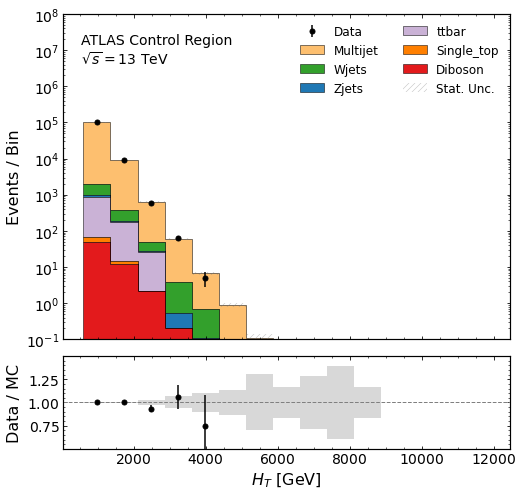

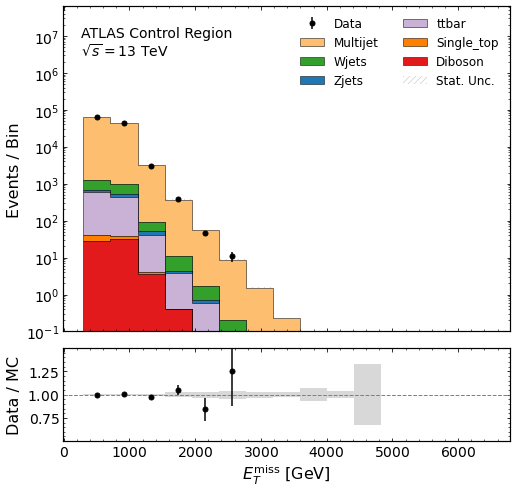

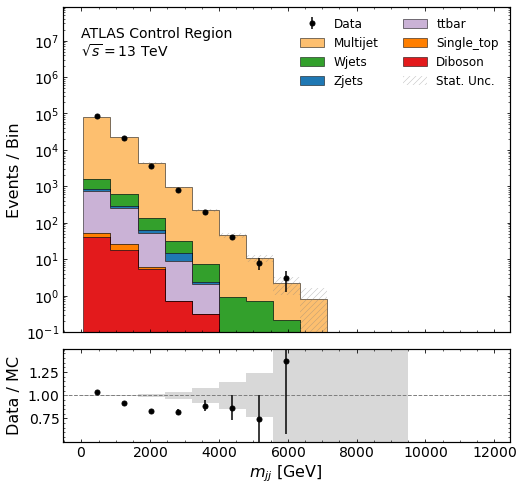

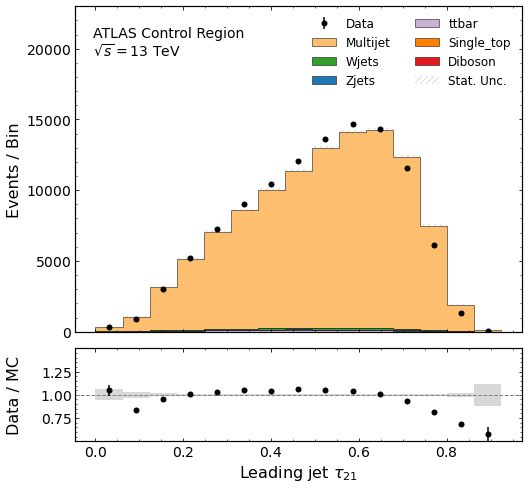

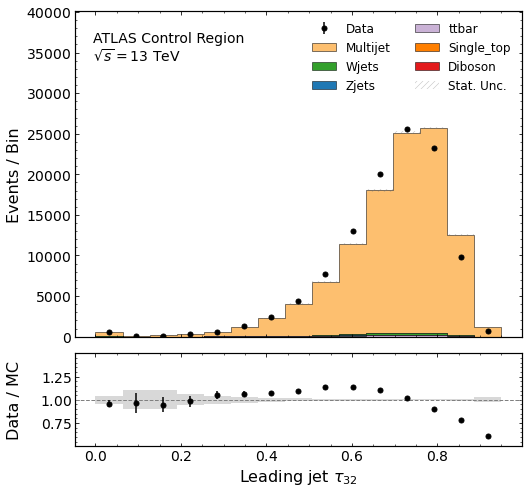

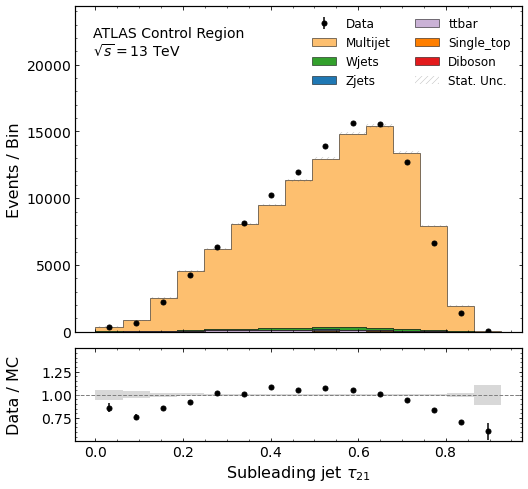

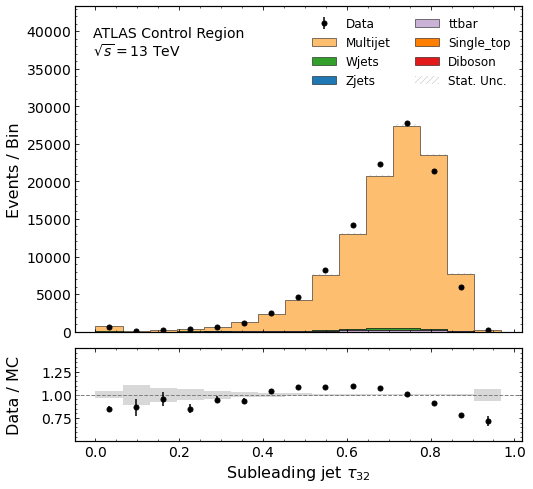

In [186]:
plot_mc_data_comparison(MC_ATLAS_TOTAL_CR_df, DATA_ATLAS_TOTAL_CR_df, "ATLAS Control Region")

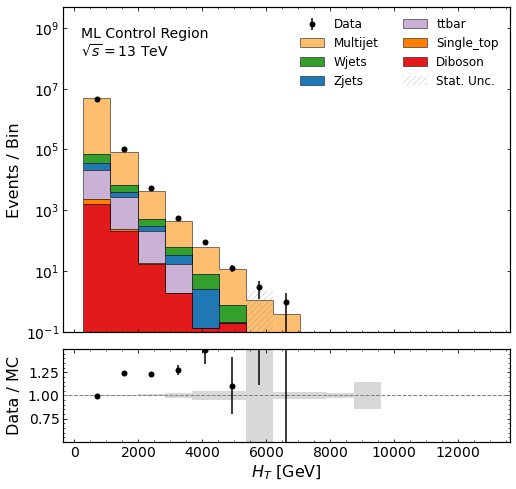

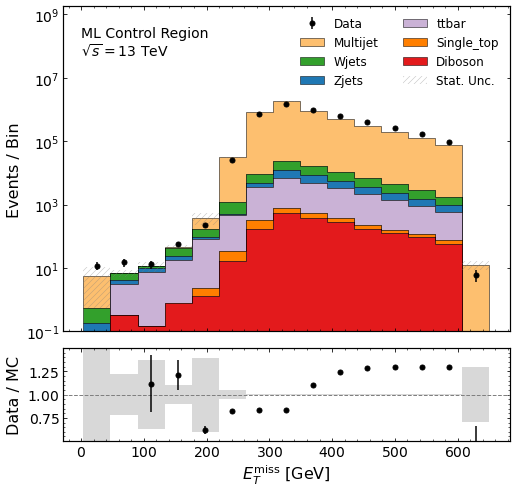

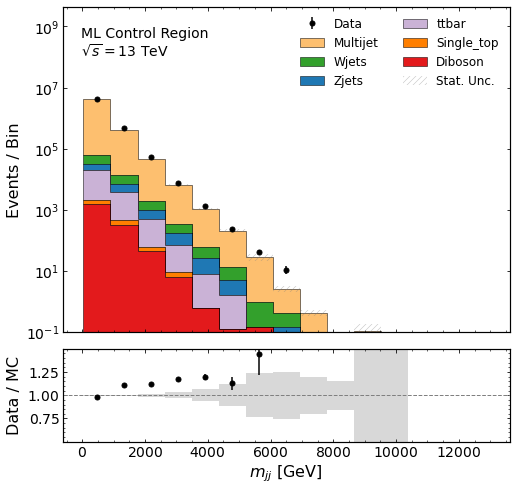

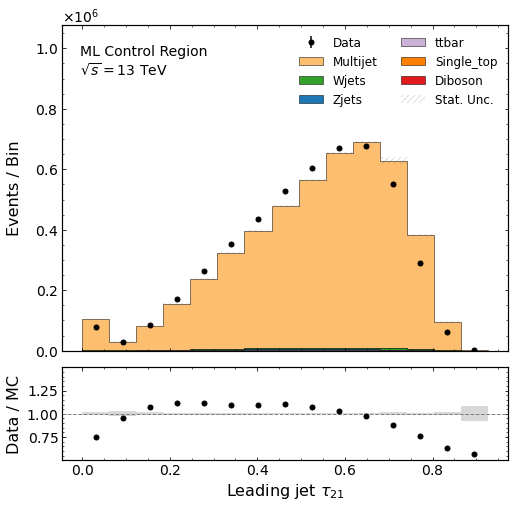

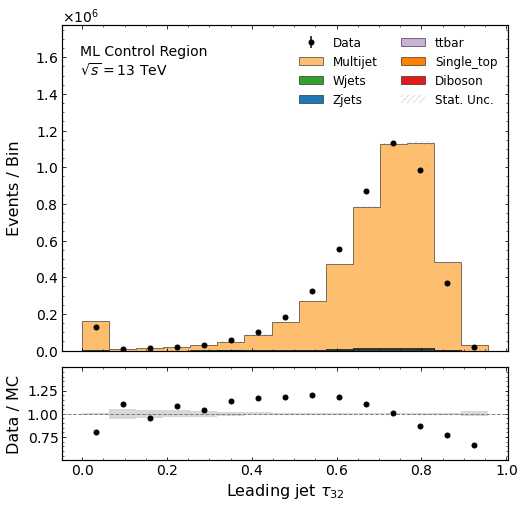

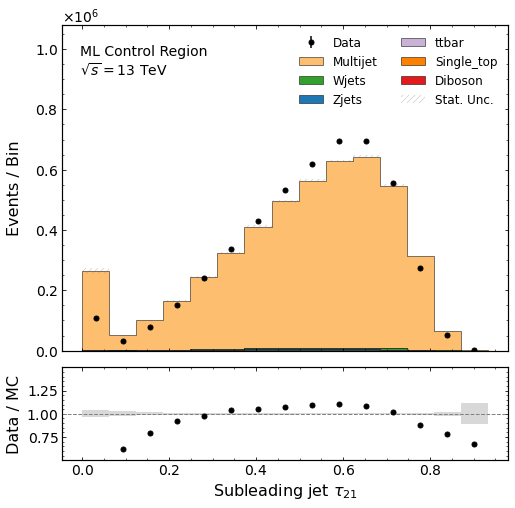

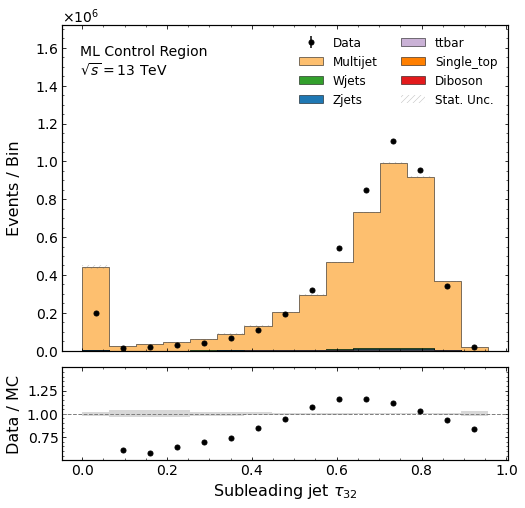

In [187]:
plot_mc_data_comparison(MC_ML_TOTAL_CR_df, DATA_ML_TOTAL_CR_df, "ML Control Region")

### Split and Scale Samples

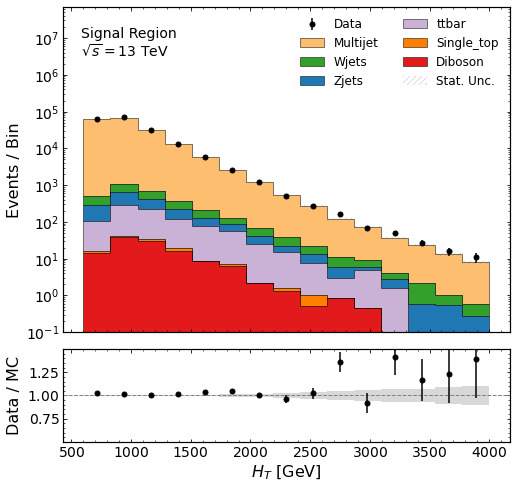

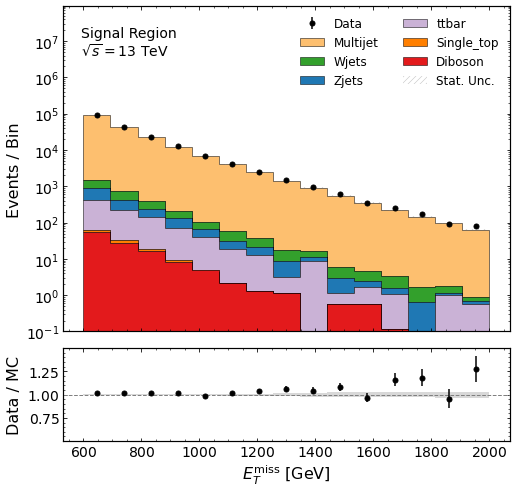

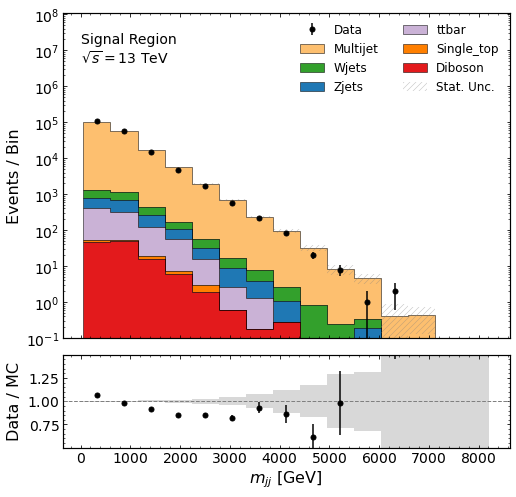

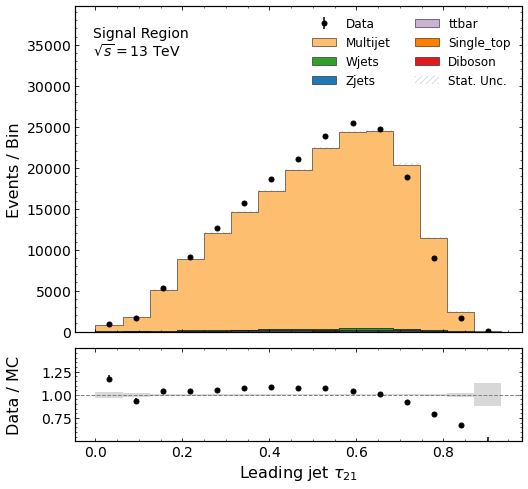

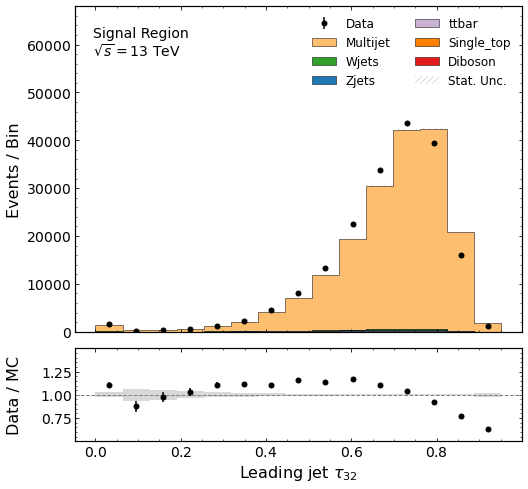

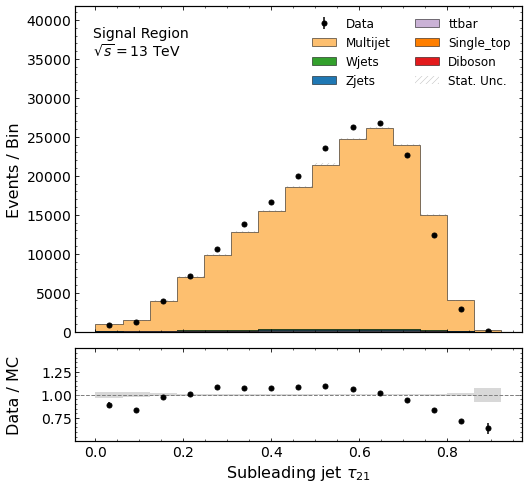

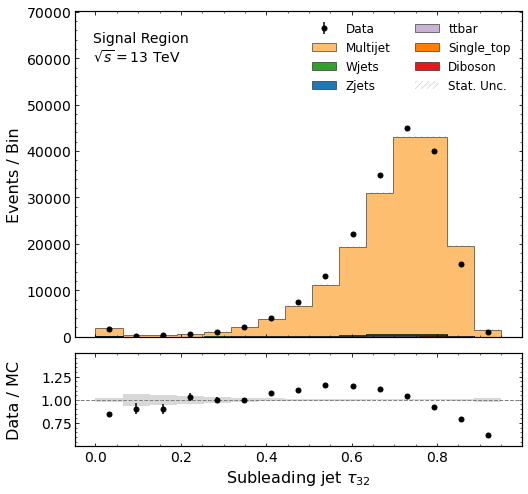

In [183]:
plot_mc_data_comparison(MC_SR_w, DATA_SR_clean, "Signal Region")

In [188]:
import os
import joblib
import numpy as np
import polars as pl
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# =====================================================================
# 1. SETUP AND FEATURE DEFINITIONS
# =====================================================================

output_dir = Path("Final_Dataset_ML")
output_dir.mkdir(parents=True, exist_ok=True)

# The exact features that the Normalizing Flow and Classifier will see
features_to_scale = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Group the existing DataFrames into dictionaries
mc_datasets = {
    "MC_CR1L": MC_ML_CR1L_w,
    "MC_CR1L1B": MC_ML_CR1L1B_w,
    "MC_CR2L": MC_ML_CR2L_w,
    "MC_CR0L": MC_ML_CR0L_w,
    "MC_SR_clean": MC_SR_w
}

data_datasets = {
    "DATA_CR1L": DATA_ML_CR1L,
    "DATA_CR1L1B": DATA_ML_CR1L1B,
    "DATA_CR2L": DATA_ML_CR2L,
    "DATA_CR0L": DATA_ML_CR0L_final,
    "DATA_SR_clean": DATA_SR_clean
}

# =====================================================================
# 2. CALCULATE AND PRINT GRANULAR TRAINING STATISTICS
# =====================================================================
print("="*85)
print(" 📊 DATASET STATISTICS (BEFORE SCALING)")
print("="*85)

all_mc_features = []

for name in mc_datasets.keys():
    region = name.replace("MC_", "")
    df_mc = mc_datasets[name]
    df_data = data_datasets.get(f"DATA_{region}")
    
    # 1. Data Count
    n_data = df_data.height if df_data is not None else 0
    
    print(f"\nREGION: {region}")
    print(f"Total Data Events: {n_data}")
    print("-" * 85)
    print(f"{'Process':<15} | {'Subprocess':<35} | {'MC Events':<10} | {'MC Yield (SumW)':<15}")
    print("-" * 85)
    
    # 2. MC Granular Breakdown
    if df_mc is not None and df_mc.height > 0:
        # Determine which weight column to sum
        weight_col = "final_weight"
        
        # Use Polars group_by for blazing fast aggregations
        mc_stats = (
            df_mc.group_by(["mc_process", "subprocess"])
            .agg([
                pl.len().alias("count"),
                pl.col(weight_col).sum().alias("yield")
            ])
            .sort(["mc_process", "subprocess"])
        )
        
        # Print the breakdown
        for row in mc_stats.iter_rows(named=True):
            print(f"{row['mc_process']:<15} | {row['subprocess']:<35} | {row['count']:<10} | {row['yield']:<15.2f}")
            
        # Add to our global boundaries collection
        all_mc_features.append(df_mc.select(features_to_scale))
    else:
        print("No MC data found for this region.")

print("\n--- Global MC Boundaries (Across All Regions) ---")
# Concatenate all MC to calculate raw boundaries and fit the scaler
df_all_mc = pl.concat(all_mc_features)
X_all_mc = df_all_mc.to_numpy()

print(f"{'Feature':<15} | {'Global Min':<12} | {'Global Max':<12}")
print("-" * 45)
for i, f in enumerate(features_to_scale):
    f_min = X_all_mc[:, i].min()
    f_max = X_all_mc[:, i].max()
    print(f"{f:<15} | {f_min:<12.2f} | {f_max:<12.2f}")
print("="*85 + "\n")

# =====================================================================
# 3. FIT SCALER ON MC ONLY AND SAVE IT
# =====================================================================
print("Fitting MinMaxScaler on combined MC...")

# Initialize the scikit-learn scaler to the (-2.5, 2.5) range
scaler = MinMaxScaler(feature_range=(-2.5, 2.5))
scaler.fit(X_all_mc)

# Save the fitted scaler to the Final_Dataset folder
scaler_path = output_dir / "minmax_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"Scaler successfully saved to {scaler_path}\n")

# =====================================================================
# 4. TRANSFORMATION FUNCTION (NUMPY <-> POLARS BRIDGE)
# =====================================================================
def scale_dataframe(df: pl.DataFrame, fitted_scaler: MinMaxScaler, features: list) -> pl.DataFrame:
    """
    Extracts features, scales them using the fitted sklearn scaler, clips outliers,
    and safely overwrites the columns in the Polars DataFrame.
    """
    X_raw = df.select(features).to_numpy()
    
    # Transform using the pre-fitted scaler
    X_scaled = fitted_scaler.transform(X_raw)
    
    # STRICT CLIPPING: Enforce the (-2.5, 2.5) bounds
    # X_scaled = np.clip(X_scaled, -2.5, 2.5)
    
    # Create a list of Polars Series to overwrite the old unscaled columns
    scaled_series = [pl.Series(name=f, values=X_scaled[:, i]) for i, f in enumerate(features)]
    
    return df.with_columns(scaled_series)

# =====================================================================
# 5. APPLY TRANSFORMATION AND EXPORT TO PARQUET
# =====================================================================
print("Applying scaler to all MC and Data regions and saving to Parquet...")

all_datasets = {**mc_datasets, **data_datasets}

for name, df in all_datasets.items():
    if df is None or df.height == 0:
        print(f"Skipping {name}: DataFrame is empty or missing.")
        continue
        
    # Scale the DataFrame using our bridge function
    scaled_df = scale_dataframe(df, scaler, features_to_scale)
    
    # Save to Parquet
    file_path = output_dir / f"{name}.parquet"
    scaled_df.write_parquet(file_path)
    
    print(f"Saved: {file_path} (Shape: {scaled_df.shape})")

print("\nPipeline complete! All data scaled and ready for PyTorch.")

 📊 DATASET STATISTICS (BEFORE SCALING)

REGION: CR1L
Total Data Events: 1730672
-------------------------------------------------------------------------------------
Process         | Subprocess                          | MC Events  | MC Yield (SumW)
-------------------------------------------------------------------------------------
Diboson         | Sh_2211_WlvWqq                      | 2560       | 308.39         
Diboson         | Sh_2211_WlvZqq                      | 903        | 118.80         
Diboson         | Sh_2211_WqqZvv                      | 225        | 24.35          
Diboson         | Sh_2211_ZqqZvv                      | 46         | 3.40           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW | 430        | 0.00           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW | 176        | 0.00           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW | 186        | 0.00           
Multijet        | Pythia8EvtGen_A14NNPDF2

In [146]:
import os
import joblib
import numpy as np
import polars as pl
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# =====================================================================
# 1. SETUP AND FEATURE DEFINITIONS
# =====================================================================

output_dir = Path("Final_Dataset_ATLAS")
output_dir.mkdir(parents=True, exist_ok=True)

# The exact features that the Normalizing Flow and Classifier will see
features_to_scale = [
    'met_recalc_pt', 'ht', 
    'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32'
]

# Group the existing DataFrames into dictionaries
mc_datasets = {
    "MC_CR1L": MC_ATLAS_CR1L_w,
    "MC_CR1L1B": MC_ATLAS_CR1L1B_w,
    "MC_CR2L": MC_ATLAS_CR2L_w,
    "MC_CR0L": MC_ATLAS_CR0L_w,
    "MC_SR_clean": MC_SR_w
}

data_datasets = {
    "DATA_CR1L": DATA_ATLAS_CR1L,
    "DATA_CR1L1B": DATA_ATLAS_CR1L1B,
    "DATA_CR2L": DATA_ATLAS_CR2L,
    "DATA_CR0L": DATA_ATLAS_CR0L_final,
    "DATA_SR_clean": DATA_SR_clean
}

# =====================================================================
# 2. CALCULATE AND PRINT GRANULAR TRAINING STATISTICS
# =====================================================================
print("="*85)
print(" 📊 DATASET STATISTICS (BEFORE SCALING)")
print("="*85)

all_mc_features = []

for name in mc_datasets.keys():
    region = name.replace("MC_", "")
    df_mc = mc_datasets[name]
    df_data = data_datasets.get(f"DATA_{region}")
    
    # 1. Data Count
    n_data = df_data.height if df_data is not None else 0
    
    print(f"\nREGION: {region}")
    print(f"Total Data Events: {n_data}")
    print("-" * 85)
    print(f"{'Process':<15} | {'Subprocess':<35} | {'MC Events':<10} | {'MC Yield (SumW)':<15}")
    print("-" * 85)
    
    # 2. MC Granular Breakdown
    if df_mc is not None and df_mc.height > 0:
        # Determine which weight column to sum
        weight_col = "final_weight"
        
        # Use Polars group_by for blazing fast aggregations
        mc_stats = (
            df_mc.group_by(["mc_process", "subprocess"])
            .agg([
                pl.len().alias("count"),
                pl.col(weight_col).sum().alias("yield")
            ])
            .sort(["mc_process", "subprocess"])
        )
        
        # Print the breakdown
        for row in mc_stats.iter_rows(named=True):
            print(f"{row['mc_process']:<15} | {row['subprocess']:<35} | {row['count']:<10} | {row['yield']:<15.2f}")
            
        # Add to our global boundaries collection
        all_mc_features.append(df_mc.select(features_to_scale))
    else:
        print("No MC data found for this region.")

print("\n--- Global MC Boundaries (Across All Regions) ---")
# Concatenate all MC to calculate raw boundaries and fit the scaler
df_all_mc = pl.concat(all_mc_features)
X_all_mc = df_all_mc.to_numpy()

print(f"{'Feature':<15} | {'Global Min':<12} | {'Global Max':<12}")
print("-" * 45)
for i, f in enumerate(features_to_scale):
    f_min = X_all_mc[:, i].min()
    f_max = X_all_mc[:, i].max()
    print(f"{f:<15} | {f_min:<12.2f} | {f_max:<12.2f}")
print("="*85 + "\n")

# =====================================================================
# 3. FIT SCALER ON MC ONLY AND SAVE IT
# =====================================================================
print("Fitting MinMaxScaler on combined MC...")

# Initialize the scikit-learn scaler to the (-2.5, 2.5) range
scaler = MinMaxScaler(feature_range=(-2.5, 2.5))
scaler.fit(X_all_mc)

# Save the fitted scaler to the Final_Dataset folder
scaler_path = output_dir / "minmax_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"Scaler successfully saved to {scaler_path}\n")

# =====================================================================
# 4. TRANSFORMATION FUNCTION (NUMPY <-> POLARS BRIDGE)
# =====================================================================
def scale_dataframe(df: pl.DataFrame, fitted_scaler: MinMaxScaler, features: list) -> pl.DataFrame:
    """
    Extracts features, scales them using the fitted sklearn scaler, clips outliers,
    and safely overwrites the columns in the Polars DataFrame.
    """
    X_raw = df.select(features).to_numpy()
    
    # Transform using the pre-fitted scaler
    X_scaled = fitted_scaler.transform(X_raw)
    
    # STRICT CLIPPING: Enforce the (-2.5, 2.5) bounds
    # X_scaled = np.clip(X_scaled, -2.5, 2.5)
    
    # Create a list of Polars Series to overwrite the old unscaled columns
    scaled_series = [pl.Series(name=f, values=X_scaled[:, i]) for i, f in enumerate(features)]
    
    return df.with_columns(scaled_series)

# =====================================================================
# 5. APPLY TRANSFORMATION AND EXPORT TO PARQUET
# =====================================================================
print("Applying scaler to all MC and Data regions and saving to Parquet...")

all_datasets = {**mc_datasets, **data_datasets}

for name, df in all_datasets.items():
    if df is None or df.height == 0:
        print(f"Skipping {name}: DataFrame is empty or missing.")
        continue
        
    # Scale the DataFrame using our bridge function
    scaled_df = scale_dataframe(df, scaler, features_to_scale)
    
    # Save to Parquet
    file_path = output_dir / f"{name}.parquet"
    scaled_df.write_parquet(file_path)
    
    print(f"Saved: {file_path} (Shape: {scaled_df.shape})")

print("\nPipeline complete! All data scaled and ready for PyTorch.")

 📊 DATASET STATISTICS (BEFORE SCALING)

REGION: CR1L
Total Data Events: 88621
-------------------------------------------------------------------------------------
Process         | Subprocess                          | MC Events  | MC Yield (SumW)
-------------------------------------------------------------------------------------
Diboson         | Sh_2211_WlvWqq                      | 567        | 34.67          
Diboson         | Sh_2211_WlvZqq                      | 202        | 14.63          
Diboson         | Sh_2211_WqqZvv                      | 53         | 3.02           
Diboson         | Sh_2211_ZqqZvv                      | 12         | 0.77           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ10WithSW | 10077      | 0.01           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ11WithSW | 4693       | 0.00           
Multijet        | Pythia8EvtGen_A14NNPDF23LO_jetjet_JZ12WithSW | 5370       | 0.00           
Multijet        | Pythia8EvtGen_A14NNPDF23L